In [1]:
import os
import matplotlib.pyplot as plt
import pandas as pd
from PIL import Image

In [2]:
import os

# Печать полного пути к текущему файлу
print(os.path.abspath("eda.ipynb"))

# Печать текущей рабочей директории
print(os.getcwd())

C:\Users\User\Downloads\winstars\winstars-test-task\task2_animal-multimodal_classifier\notebooks\eda.ipynb
C:\Users\User\Downloads\winstars\winstars-test-task\task2_animal-multimodal_classifier\notebooks


In [14]:
# Путь к датасету
data_dir = "../data/raw-img"

classes = os.listdir(data_dir)

print("Number of classes:", len(classes))
print(classes)

Number of classes: 10
['butterfly', 'cat', 'chicken', 'cow', 'dog', 'elephant', 'horse', 'sheep', 'spider', 'squirrel']


In [13]:
# Посчитать количество изображений
counts = {}

for cls in classes:
    path = os.path.join(data_dir, cls)
    counts[cls] = len(os.listdir(path))

df = pd.DataFrame.from_dict(counts, orient="index", columns=["images"])
df

,images
butterfly,2112
cat,1668
chicken,3098
cow,1866
dog,4863
elephant,1446
horse,2623
sheep,1820
spider,4821
squirrel,1862


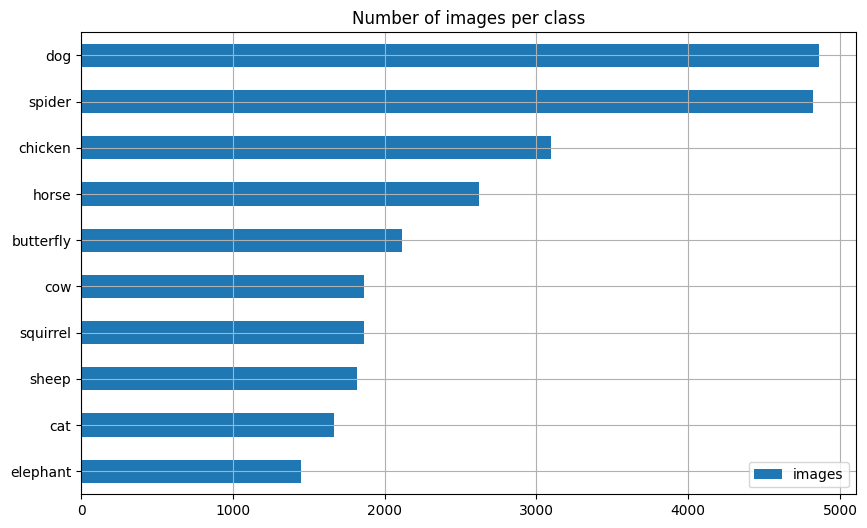

In [6]:
# Построить график распределения
df.sort_values("images").plot(
    kind="barh",
    figsize=(10,6),
    title="Number of images per class"
)
plt.grid(True)
plt.show()

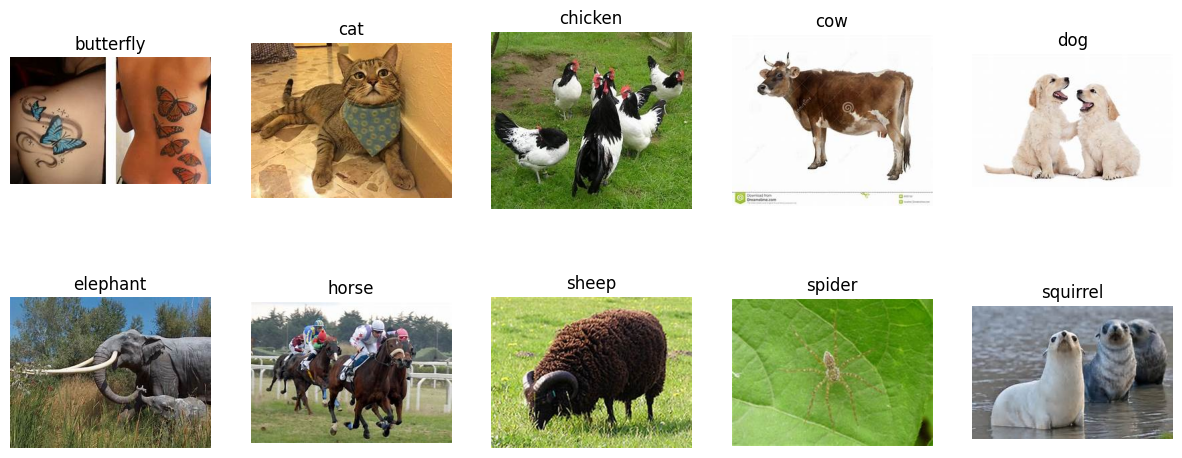

In [7]:
# Показать примеры изображений
import random

fig, axes = plt.subplots(2,5, figsize=(15,6))

for ax, cls in zip(axes.flatten(), classes):

    img_path = os.path.join(
        data_dir,
        cls,
        random.choice(os.listdir(os.path.join(data_dir, cls)))
    )

    img = Image.open(img_path)

    ax.imshow(img)
    ax.set_title(cls)
    ax.axis("off")

plt.show()

In [8]:
#  Проверить размеры изображений
sizes = []

for cls in classes:
    folder = os.path.join(data_dir, cls)

    for img_name in os.listdir(folder)[:50]:
        img = Image.open(os.path.join(folder, img_name))
        sizes.append(img.size)

sizes[:10]

[(426, 640),
 (640, 457),
 (426, 640),
 (425, 640),
 (426, 640),
 (640, 454),
 (640, 426),
 (640, 439),
 (640, 416),
 (640, 375)]